# Data understanding 

In [1]:
# Data understanding 

import pandas as pd
dataset_original=pd.read_csv("ai4i2020.csv") #copy of original dataset
dataset = dataset_original
dataset_original.head()



,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
dataset.shape

(10000, 14)

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [4]:
'''
1.	UID: unique identifier ranging from 1 to 10000
2.	product ID: consisting of a letter L, M, or H for low (50% of all products), medium (30%) and high (20%) as product quality variants and a variant-specific serial number
3.	type: just the product type L, M or H from column 2
4.	air temperature [K]: generated using a random walk process later normalized to a standard deviation of 2 K around 300 K
5.	process temperature [K]: generated using a random walk process normalized to a standard deviation of 1 K, added to the air temperature plus 10 K.
6.	rotational speed [rpm]: calculated from a power of 2860 W, overlaid with a normally distributed noise
7.	torque [Nm]: torque values are normally distributed around 40 Nm with a SD = 10 Nm and no negative values.
8.	tool wear [min]: The quality variants H/M/L add 5/3/2 minutes of tool wear to the used tool in the process.
9.	a 'machine failure' label that indicates, whether the machine has failed in this particular datapoint for any of the following failure modes are true.
'''


"\n1.\tUID: unique identifier ranging from 1 to 10000\n2.\tproduct ID: consisting of a letter L, M, or H for low (50% of all products), medium (30%) and high (20%) as product quality variants and a variant-specific serial number\n3.\ttype: just the product type L, M or H from column 2\n4.\tair temperature [K]: generated using a random walk process later normalized to a standard deviation of 2 K around 300 K\n5.\tprocess temperature [K]: generated using a random walk process normalized to a standard deviation of 1 K, added to the air temperature plus 10 K.\n6.\trotational speed [rpm]: calculated from a power of 2860 W, overlaid with a normally distributed noise\n7.\ttorque [Nm]: torque values are normally distributed around 40 Nm with a SD = 10 Nm and no negative values.\n8.\ttool wear [min]: The quality variants H/M/L add 5/3/2 minutes of tool wear to the used tool in the process.\n9.\ta 'machine failure' label that indicates, whether the machine has failed in this particular datapoint

In [5]:
dataset.describe()


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


# handling missing values

In [6]:

# handling missing values

# their is no null values in this dataset 
dataset.isnull().sum()
dataset.isna().sum()


UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

# Remove unwanted columns 

In [7]:
# Remove unwanted columns 
# drop the 'Product ID','UDI' - as it is unique product information - not required for model training 
dataset = dataset.drop(['Product ID','UDI', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',],axis=1)
dataset 



,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0
...,...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14,0
9996,H,298.9,308.4,1632,31.8,17,0
9997,M,299.0,308.6,1645,33.4,22,0
9998,H,299.0,308.7,1408,48.5,25,0


# Encoding - Preprocessing 
###  convert categorical data into numerical data

In [8]:
# Encoding - Preprocessing 
## convert categorical data into numerical data

from sklearn.preprocessing import LabelEncoder 
label_encoder = LabelEncoder()
dataset['Type'] = label_encoder.fit_transform(dataset['Type'])  
'''  # LabelEncoder assigns values based on alphabetical order
L  -> 1
M  -> 2
H  -> 0
'''

'  # LabelEncoder assigns values based on alphabetical order\nL  -> 1\nM  -> 2\nH  -> 0\n'

### save the labelEncoder preprocessing

In [9]:
import pickle 
with open('lable_encoder.sav','wb') as file:
    pickle.dump(label_encoder, file)

In [10]:
'''Type
L    6000
M    2997
H    1003
Name: count, dtype: int64'''   #before

dataset['Type'].value_counts()  # after

Type
1    6000
2    2997
0    1003
Name: count, dtype: int64

# Feature Engineering 

In [11]:
# adding new feature - Temp_diff -> thermal stress
dataset['Temp_diff [K]'] = dataset['Process temperature [K]'] - dataset['Air temperature [K]']
dataset

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temp_diff [K]
0,2,298.1,308.6,1551,42.8,0,0,10.5
1,1,298.2,308.7,1408,46.3,3,0,10.5
2,1,298.1,308.5,1498,49.4,5,0,10.4
3,1,298.2,308.6,1433,39.5,7,0,10.4
4,1,298.2,308.7,1408,40.0,9,0,10.5
...,...,...,...,...,...,...,...,...
9995,2,298.8,308.4,1604,29.5,14,0,9.6
9996,0,298.9,308.4,1632,31.8,17,0,9.5
9997,2,299.0,308.6,1645,33.4,22,0,9.6
9998,0,299.0,308.7,1408,48.5,25,0,9.7


In [27]:
dataset['power'] = dataset['Torque [Nm]'] * dataset['Rotational speed [rpm]']
dataset['wear_rate'] = dataset['Tool wear [min]'] / dataset['Rotational speed [rpm]']
dataset

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temp_diff [K],power,wear_rate
0,2,298.1,308.6,1551,42.8,0,0,10.5,66382.8,0.000000
1,1,298.2,308.7,1408,46.3,3,0,10.5,65190.4,0.002131
2,1,298.1,308.5,1498,49.4,5,0,10.4,74001.2,0.003338
3,1,298.2,308.6,1433,39.5,7,0,10.4,56603.5,0.004885
4,1,298.2,308.7,1408,40.0,9,0,10.5,56320.0,0.006392
...,...,...,...,...,...,...,...,...,...,...
9995,2,298.8,308.4,1604,29.5,14,0,9.6,47318.0,0.008728
9996,0,298.9,308.4,1632,31.8,17,0,9.5,51897.6,0.010417
9997,2,299.0,308.6,1645,33.4,22,0,9.6,54943.0,0.013374
9998,0,299.0,308.7,1408,48.5,25,0,9.7,68288.0,0.017756


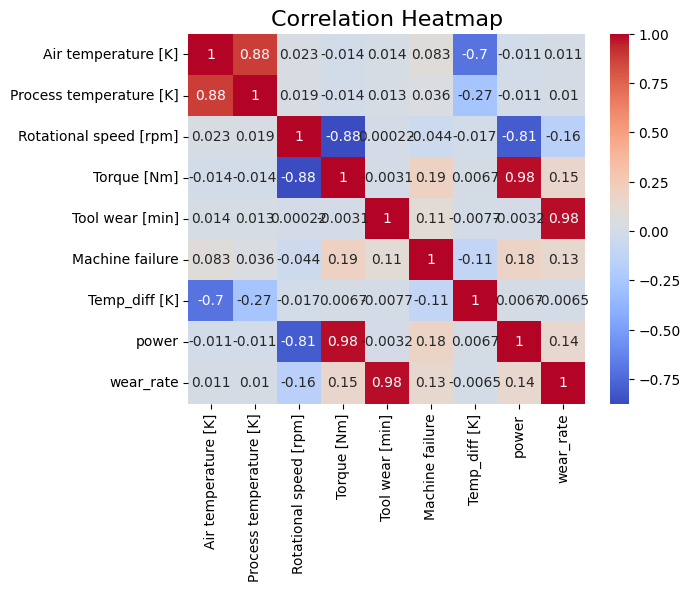

In [28]:
correlation_matrix = dataset[[
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'Temp_diff [K]',
 'power',
 'wear_rate']].corr()

import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

# ---- both handlied in model creation -- sclaing + handle  imbalance 

# Scaling 

In [13]:
x = dataset.drop(['Machine failure'],axis=1)
x
# using Robust Scaler --> Keeps the exact extreme values but scales the "normal" data around them.
from sklearn.preprocessing import RobustScaler
transformer = RobustScaler()
x = transformer.fit_transform(x)
pd.DataFrame(x)

,0,1,2,3,4,5,6
0,1.0,-0.62500,-0.652174,0.253968,0.198529,-0.990826,0.411765
1,0.0,-0.59375,-0.608696,-0.502646,0.455882,-0.963303,0.411765
2,0.0,-0.62500,-0.695652,-0.026455,0.683824,-0.944954,0.352941
3,0.0,-0.59375,-0.652174,-0.370370,-0.044118,-0.926606,0.352941
4,0.0,-0.59375,-0.608696,-0.502646,-0.007353,-0.908257,0.411765
...,...,...,...,...,...,...,...
9995,1.0,-0.40625,-0.739130,0.534392,-0.779412,-0.862385,-0.117647
9996,-1.0,-0.37500,-0.739130,0.682540,-0.610294,-0.834862,-0.176471
9997,1.0,-0.34375,-0.652174,0.751323,-0.492647,-0.788991,-0.117647
9998,-1.0,-0.34375,-0.608696,-0.502646,0.617647,-0.761468,-0.058824


# handling class imbalance 

In [14]:
# handling class imbalance 
dataset['Machine failure'].value_counts()
# imbalanced data --- i will handle it via model training (class_weights) and evaluation metric (f1 score, precision , recall)

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [15]:
# x = dataset.drop(['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],axis=1)
x

array([[ 1.        , -0.625     , -0.65217391, ...,  0.19852941,
        -0.99082569,  0.41176471],
       [ 0.        , -0.59375   , -0.60869565, ...,  0.45588235,
        -0.96330275,  0.41176471],
       [ 0.        , -0.625     , -0.69565217, ...,  0.68382353,
        -0.94495413,  0.35294118],
       ...,
       [ 1.        , -0.34375   , -0.65217391, ..., -0.49264706,
        -0.78899083, -0.11764706],
       [-1.        , -0.34375   , -0.60869565, ...,  0.61764706,
        -0.76146789, -0.05882353],
       [ 1.        , -0.34375   , -0.60869565, ...,  0.00735294,
        -0.71559633, -0.05882353]])

In [16]:
y = dataset['Machine failure']
y

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: Machine failure, Length: 10000, dtype: int64

In [17]:
y.value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [18]:
# !pip install imbalanced-learn

In [19]:
from imblearn.over_sampling import SMOTE    # need to be applied only in training data - to avoid data leakage
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(x, y)

In [20]:
X_resampled, y_resampled

(array([[ 1.        , -0.625     , -0.65217391, ...,  0.19852941,
         -0.99082569,  0.41176471],
        [ 0.        , -0.59375   , -0.60869565, ...,  0.45588235,
         -0.96330275,  0.41176471],
        [ 0.        , -0.625     , -0.69565217, ...,  0.68382353,
         -0.94495413,  0.35294118],
        ...,
        [ 0.        , -0.22610705,  0.26086957, ..., -1.0832523 ,
          0.99245072,  0.89620151],
        [ 0.54790648,  0.12200585,  0.0631345 , ..., -0.70588235,
          1.0854533 , -0.02659374],
        [ 1.        ,  0.60947374,  0.09122192, ...,  0.60077711,
         -0.22732582, -0.90617973]]),
 0        0
 1        0
 2        0
 3        0
 4        0
         ..
 19317    1
 19318    1
 19319    1
 19320    1
 19321    1
 Name: Machine failure, Length: 19322, dtype: int64)

In [21]:
y_resampled.value_counts()    # now we get the balanced dataset with equal no of samples for machine non failure and machine failure using SMOTE

Machine failure
0    9661
1    9661
Name: count, dtype: int64

In [22]:
dataset

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temp_diff [K]
0,2,298.1,308.6,1551,42.8,0,0,10.5
1,1,298.2,308.7,1408,46.3,3,0,10.5
2,1,298.1,308.5,1498,49.4,5,0,10.4
3,1,298.2,308.6,1433,39.5,7,0,10.4
4,1,298.2,308.7,1408,40.0,9,0,10.5
...,...,...,...,...,...,...,...,...
9995,2,298.8,308.4,1604,29.5,14,0,9.6
9996,0,298.9,308.4,1632,31.8,17,0,9.5
9997,2,299.0,308.6,1645,33.4,22,0,9.6
9998,0,299.0,308.7,1408,48.5,25,0,9.7


# KEY NOTE: INITIAL PREPROCESSING 

KEY NOTE: INITIAL PREPROCESSING 

I started my predictive maintenance machine learning project by first understanding the dataset. I loaded the dataset and examined its shape, which contains 10,000 rows and 14 columns. Using the .info() function, I identified the data types and observed that UID and Product ID are unique identifier columns, Type is a categorical feature, and the remaining variables such as air temperature, process temperature, rotational speed, torque, and tool wear are numerical features. The target variable is Machine failure, which represents whether a failure has occurred. I then used descriptive statistics to understand the distribution, central tendency, and variability of the features. After that, I checked for missing values and found that the dataset has no null values, so no imputation was required. I removed irrelevant columns like UID and Product ID as they do not contribute to the prediction task. To handle the categorical variable Type, I applied encoding to convert it into a numerical format. Finally, I analyzed the target variable distribution and found that the dataset is imbalanced, which is an important consideration for model building. These steps formed the initial preprocessing phase before proceeding to exploratory data analysis.

FEATURE ENGINEERING

After initial preprocessing, I ensured there was no data leakage by removing failure-type columns. I also performed minimal feature engineering by creating a new feature, Temp_diff, which represents the difference between process temperature and air temperature to capture thermal stress. Since the dataset had clean numerical features and no missing values, no additional preprocessing was required. Scaling and Handling imbalanced dataset will be done during the model creation phase


In [29]:
dataset

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temp_diff [K],power,wear_rate
0,2,298.1,308.6,1551,42.8,0,0,10.5,66382.8,0.000000
1,1,298.2,308.7,1408,46.3,3,0,10.5,65190.4,0.002131
2,1,298.1,308.5,1498,49.4,5,0,10.4,74001.2,0.003338
3,1,298.2,308.6,1433,39.5,7,0,10.4,56603.5,0.004885
4,1,298.2,308.7,1408,40.0,9,0,10.5,56320.0,0.006392
...,...,...,...,...,...,...,...,...,...,...
9995,2,298.8,308.4,1604,29.5,14,0,9.6,47318.0,0.008728
9996,0,298.9,308.4,1632,31.8,17,0,9.5,51897.6,0.010417
9997,2,299.0,308.6,1645,33.4,22,0,9.6,54943.0,0.013374
9998,0,299.0,308.7,1408,48.5,25,0,9.7,68288.0,0.017756


In [30]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  int32  
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Machine failure          10000 non-null  int64  
 7   Temp_diff [K]            10000 non-null  float64
 8   power                    10000 non-null  float64
 9   wear_rate                10000 non-null  float64
dtypes: float64(6), int32(1), int64(3)
memory usage: 742.3 KB


# save the preprocessed - predictive maintenance dataset

In [31]:
dataset.to_csv('processed_ai4i2020.csv',index=False)